# Convolutional Neural Networks and Computer Vision Using TensorFlow


We're going to get specific and see how a special kind of neural network, [convolutional neural networks (CNNs)](https://en.wikipedia.org/wiki/Convolutional_neural_network) can be used for computer vision (detecting patterns in visual data).

In deep learning, many different kinds of model architectures can be used for different problems. For example, you could use a convolutional neural network for making predictions on image data and/or text data. However, in practice some architectures typically work better than others.

For example, you might want to:
* Classify whether a picture of food contains pizza 🍕 or steak 🥩 (we're going to do this)
* Detect whether or not an object appears in an image (e.g. did a specific car pass through a security camera?)


## What we're going to cover

Specifically, we're going to go through the follow with TensorFlow:

- Getting a dataset to work with
- Architecture of a convolutional neural network
- A quick end-to-end example (what we're working towards)
- Steps in modelling for binary image classification with CNNs
  - Becoming one with the data
  - Preparing data for modelling
  - Creating a CNN model (starting with a baseline)
  - Fitting a model (getting it to find patterns in our data)
  - Evaluating a model
  - Improving a model
  - Making a prediction with a trained model
- Steps in modelling for multi-class image classification with CNNs
 - Same as above (but this time with a different dataset).

## Get the data

The images we're going to work with are from the [Food-101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/), a collection of 101 different categories of 101,000 (1000 images per category) real-world images of food dishes. 

To begin, we're only going to use two of the categories, pizza 🍕 and steak 🥩 and build a binary classifier.

We'll download the [pizza_steak](https://www.google.com/url?sa=E&source=gmail&q=https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip) subset .zip file and unzip it.

## Inspect the data

A very crucial step at the beginning of any machine learning project is becoming one with the data. This usually means plenty of visualizing and folder scanning to understand the data you're working with.

The file structure has been formatted to be in a typical format we might use for working with images.

More specifically:
* A `train` directory which contains all of the images in the training dataset with subdirectories each named after a certain class containing images of that class.
* A `test` directory with the same structure as the `train` directory.

```
Example of file structure

pizza_steak <- top level folder
└───train <- training images
│   └───pizza
│   │   │   1008104.jpg
│   │   │   1638227.jpg
│   │   │   ...      
│   └───steak
│       │   1000205.jpg
│       │   1647351.jpg
│       │   ...
│   
└───test <- testing images
│   └───pizza
│   │   │   1001116.jpg
│   │   │   1507019.jpg
│   │   │   ...      
│   └───steak
│       │   100274.jpg
│       │   1653815.jpg
│       │   ...    
 ```

In [1]:
import os

os.listdir('pizza_steak/')

['train', 'test']

In [2]:
# Walking through Pizza_Steak Directory and List Number of Files:

for dirpath, dirnames, filenames in os.walk('pizza_steak/'):
    print(f'There are {len(dirnames)} Directories and {len(filenames)} Images in {dirpath}')

There are 2 Directories and 0 Images in pizza_steak/
There are 2 Directories and 0 Images in pizza_steak/train
There are 0 Directories and 750 Images in pizza_steak/train/pizza
There are 0 Directories and 750 Images in pizza_steak/train/steak
There are 2 Directories and 0 Images in pizza_steak/test
There are 0 Directories and 250 Images in pizza_steak/test/pizza
There are 0 Directories and 250 Images in pizza_steak/test/steak


In [3]:
# Getting Names of Classes Programmatically:

import pathlib
import numpy as np

datadir = pathlib.Path('pizza_steak/train/')
class_names = np.array(sorted(item.name for item in datadir.glob('*')))

In [4]:
class_names

array(['pizza', 'steak'], dtype='<U5')

In [5]:
list(datadir.glob('*'))

[PosixPath('pizza_steak/train/pizza'), PosixPath('pizza_steak/train/steak')]

In [6]:
# Viewing an Image:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):

    # Setting Up Directory to View Image:
    target_folder = target_dir+target_class

    # Getting a Random Image Path:
    random_image = random.sample(os.listdir(target_folder), 1)

    # Reading in The Selected Image and Plotting it:
    img = plt.imread(target_folder+'/'+random_image[0])
    plt.imshow(img)
    plt.title(target_class)

    return img

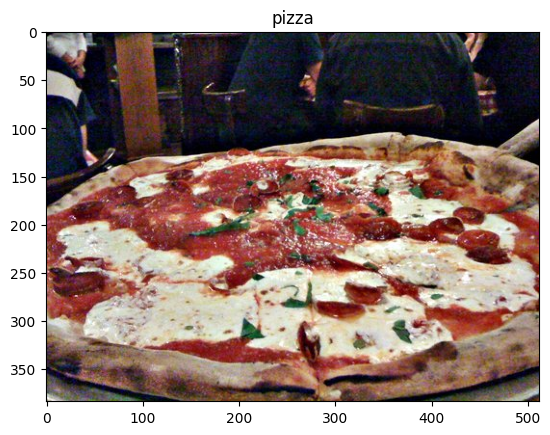

In [7]:
image = view_random_image(target_dir= 'pizza_steak/train/',
                         target_class= 'pizza')

In [8]:
image

array([[[  0,   7,  17],
        [  0,   6,  16],
        [  0,   2,  15],
        ...,
        [ 26,  48,  35],
        [ 32,  57,  28],
        [ 21,  49,  11]],

       [[  0,   1,   7],
        [  0,   1,   9],
        [  0,   4,  16],
        ...,
        [ 23,  43,  32],
        [ 29,  52,  32],
        [ 27,  51,  25]],

       [[  0,   2,   0],
        [  1,   1,   0],
        [  1,   0,   9],
        ...,
        [ 18,  35,  29],
        [ 22,  38,  37],
        [ 25,  44,  42]],

       ...,

       [[209, 207, 194],
        [239, 237, 225],
        [255, 255, 250],
        ...,
        [ 70,  43,  32],
        [ 77,  47,  39],
        [ 92,  59,  52]],

       [[169, 166, 151],
        [187, 184, 169],
        [232, 229, 214],
        ...,
        [ 85,  50,  22],
        [102,  61,  39],
        [105,  62,  43]],

       [[167, 161, 145],
        [147, 141, 125],
        [187, 182, 163],
        ...,
        [ 84,  46,   7],
        [111,  66,  37],
        [102,  55,  29]]

In [9]:
image.shape

(384, 512, 3)

Looking at the image shape more closely, you'll see it's in the form `(Width, Height, Colour Channels)`.

In our case, the width and height vary but because we're dealing with colour images, the colour channels value is always 3. This is for different values of [red, green and blue (RGB) pixels](https://en.wikipedia.org/wiki/RGB_color_model).

You'll notice all of the values in the `img` array are between 0 and 255. This is because that's the possible range for red, green and blue values.

For example, a pixel with a value `red=0, green=0, blue=255` will look very blue.

So when we build a model to differentiate between our images of `pizza` and `steak`, it will be finding patterns in these different pixel values which determine what each class looks like.

Many machine learning models, including neural networks prefer the values they work with to be between 0 and 1. Knowing this, one of the most common preprocessing steps for working with images is to **scale** (also referred to as **normalize**) their pixel values by dividing the image arrays by 255.

In [10]:
image.min(), image.max()

(0, 255)

In [11]:
# Getting all Pixel values Between 0 and 1:
image/255

array([[[0.        , 0.02745098, 0.06666667],
        [0.        , 0.02352941, 0.0627451 ],
        [0.        , 0.00784314, 0.05882353],
        ...,
        [0.10196078, 0.18823529, 0.1372549 ],
        [0.1254902 , 0.22352941, 0.10980392],
        [0.08235294, 0.19215686, 0.04313725]],

       [[0.        , 0.00392157, 0.02745098],
        [0.        , 0.00392157, 0.03529412],
        [0.        , 0.01568627, 0.0627451 ],
        ...,
        [0.09019608, 0.16862745, 0.1254902 ],
        [0.11372549, 0.20392157, 0.1254902 ],
        [0.10588235, 0.2       , 0.09803922]],

       [[0.        , 0.00784314, 0.        ],
        [0.00392157, 0.00392157, 0.        ],
        [0.00392157, 0.        , 0.03529412],
        ...,
        [0.07058824, 0.1372549 , 0.11372549],
        [0.08627451, 0.14901961, 0.14509804],
        [0.09803922, 0.17254902, 0.16470588]],

       ...,

       [[0.81960784, 0.81176471, 0.76078431],
        [0.9372549 , 0.92941176, 0.88235294],
        [1.        , 1

## A (typical) architecture of a convolutional neural network

Components of a convolutional neural network:

| **Hyperparameter/Layer type** | **What does it do?** | **Typical values** |
| ----- | ----- | ----- |
| Input image(s) | Target images you'd like to discover patterns in| Whatever you can take a photo (or video) of |
| Input layer | Takes in target images and preprocesses them for further layers | `input_shape = [batch_size, image_height, image_width, color_channels]` |
| Convolution layer | Extracts/learns the most important features from target images | Multiple, can create with [`tf.keras.layers.ConvXD`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) (X can be multiple values) |
| Hidden activation | Adds non-linearity to learned features (non-straight lines) | Usually ReLU ([`tf.keras.activations.relu`](https://www.tensorflow.org/api_docs/python/tf/keras/activations/relu)) |
| Pooling layer | Reduces the dimensionality of learned image features | Average ([`tf.keras.layers.AvgPool2D`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/AveragePooling2D)) or Max ([`tf.keras.layers.MaxPool2D`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D)) |
| Fully connected layer | Further refines learned features from convolution layers | [`tf.keras.layers.Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) |
| Output layer | Takes learned features and outputs them in shape of target labels | `output_shape = [number_of_classes]` (e.g. 3 for pizza, steak or sushi)|
| Output activation | Adds non-linearities to output layer | [`tf.keras.activations.sigmoid`](https://www.tensorflow.org/api_docs/python/tf/keras/activations/sigmoid) (binary classification) or [`tf.keras.activations.softmax`](https://www.tensorflow.org/api_docs/python/tf/keras/activations/softmax) |

How they stack together:

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-simple-convnet.png)

**Great Resource to Understand CNN**

https://poloclub.github.io/cnn-explainer/

# An End-to-End Example:

In [12]:
# Importing Necessary Libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

2026-01-09 12:29:45.912321: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 12:29:46.913521: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 12:29:50.032232: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/export/tf2onnx_li

In [13]:
# Building Convolutional Neural Network:

tf.random.set_seed(42)

# Pre-Processing Data (Getting all pixel values between 0 and 1):
train_datagen = ImageDataGenerator(rescale= 1/255.0)
valid_datagen = ImageDataGenerator(rescale= 1/255.0)

# Setting up Path to Directories:
train_dir = 'pizza_steak/train'
test_dir = 'pizza_steak/test'

# Importing Images from Directories and Turn it into Batches:
train_data = train_datagen.flow_from_directory(directory= train_dir,
                                              target_size= (224,224),
                                              batch_size= 32,
                                              class_mode= 'binary',
                                              seed= 42)

valid_data = valid_datagen.flow_from_directory(directory= test_dir,
                                              target_size= (224,224),
                                              batch_size= 32,
                                              class_mode= 'binary',
                                              seed= 42)


# Creating a CNN Model:
model_1 = Sequential()

model_1.add(InputLayer(shape= (224, 224, 3)))

model_1.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))

model_1.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))

model_1.add(MaxPool2D(pool_size= 2,
                     padding= 'valid'))

model_1.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))

model_1.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))

model_1.add(MaxPool2D(pool_size= 2))

model_1.add(Flatten())

model_1.add(Dense(units= 1, activation= 'sigmoid'))

model_1.compile(optimizer= tf.keras.optimizers.Adam(),
               loss= tf.keras.losses.BinaryCrossentropy(),
               metrics= ['accuracy'])

history_1 = model_1.fit(train_data,
                       epochs= 5,
                       validation_data= valid_data)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


I0000 00:00:1767961795.993454     673 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/5


2026-01-09 12:29:59.987071: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b47cc006570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-09 12:29:59.987111: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-01-09 12:30:00.059225: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-09 12:30:00.362587: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


 3/47 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4844 - loss: 0.6921

I0000 00:00:1767961804.662687     898 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.6953 - loss: 0.5809 - val_accuracy: 0.8200 - val_loss: 0.4490
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.7733 - loss: 0.4724 - val_accuracy: 0.8320 - val_loss: 0.4063
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.8120 - loss: 0.4245 - val_accuracy: 0.8480 - val_loss: 0.3502
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8340 - loss: 0.3898 - val_accuracy: 0.8640 - val_loss: 0.3303
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8427 - loss: 0.3541 - val_accuracy: 0.8480 - val_loss: 0.3691


In [14]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

#### Using the same model as before

To examplify how neural networks can be adapted to many different problems, let's see how a binary classification model we've previously built might work with our data.

We can use all of the same parameters in our previous model except for changing two things:
* **The data** - we're now working with images instead of dots.
* **The input shape** - we have to tell our neural network the shape of the images we're working with.
  * A common practice is to reshape images all to one size. In our case, we'll resize the images to `(224, 224, 3)`, meaning a height and width of 224 pixels and a depth of 3 for the red, green, blue colour channels.

In [15]:
tf.random.set_seed(42)

model_2 = Sequential()

model_2.add(InputLayer(shape= (224, 224, 3)))
model_2.add(Flatten())

model_2.add(Dense(units= 4, activation= 'relu'))
model_2.add(Dense(units= 4, activation= 'relu'))
model_2.add(Dense(units= 1, activation= 'sigmoid'))

model_2.compile(optimizer= tf.keras.optimizers.Adam(),
               loss= tf.keras.losses.BinaryCrossentropy(),
               metrics= ['accuracy'])

history_2 = model_2.fit(train_data,
                       epochs= 5,
                       validation_data= valid_data)

Epoch 1/5


2026-01-09 12:30:32.193176: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_120', 4 bytes spill stores, 4 bytes spill loads

2026-01-09 12:30:32.226910: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_120', 4 bytes spill stores, 4 bytes spill loads



14/47 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5046 - loss: 0.9975

2026-01-09 12:30:34.870822: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_120', 4 bytes spill stores, 4 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.4925 - loss: 0.8318

2026-01-09 12:30:39.877621: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_20', 4 bytes spill stores, 4 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.4933 - loss: 0.7335 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.4760 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


In [16]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

One of the most noticeable things here is the much larger number of parameters in `model_2` versus `model_1`.

`model_2` has 602,141 trainable parameters where as `model_1` has only 31,101. And despite this difference, `model_1` still far and large out performs `model_2`.

You can think of trainable parameters as *patterns a model can learn from data*. Intuitiely, you might think more is better. And in some cases it is. But in this case, the difference here is in the two different styles of model we're using. Where a series of dense layers have a number of different learnable parameters connected to each other and hence a higher number of possible learnable patterns, **a convolutional neural network seeks to sort out and learn the most important patterns in an image**. So even though there are less learnable parameters in our convolutional neural network, these are often more helpful in deciphering between different **features** in an image.

Since our previous model didn't work we will increase the number of layers and even increase the number of neurons in each layer.

More specifically, we'll increase the number of neurons (also called hidden units) in each dense layer from 4 to 100 and add an extra layer.

Adding extra layers or increasing the number of neurons in each layer is often referred to as increasing the **complexity** of your model.

In [17]:
tf.random.set_seed(42)

model_3 = Sequential()

model_3.add(InputLayer(shape= (224,224,3)))
model_3.add(Flatten())
model_3.add(Dense(units= 100, activation= 'relu'))
model_3.add(Dense(units= 100, activation= 'relu'))
model_3.add(Dense(units= 100, activation= 'relu'))
model_3.add(Dense(units= 1, activation= 'sigmoid'))

model_3.compile(optimizer= tf.keras.optimizers.Adam(),
               loss= tf.keras.losses.BinaryCrossentropy(),
               metrics= ['accuracy'])

model_3.fit(train_data,
           epochs= 5,
           validation_data= valid_data)

Epoch 1/5


2026-01-09 12:30:57.454154: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-09 12:30:57.454233: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-09 12:30:57.454260: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-09 12:30:57.454273: I external/l

39/47 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5177 - loss: 4.5189

2026-01-09 12:31:04.124678: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-09 12:31:04.124763: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-09 12:31:05.256216: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_161', 20 bytes spill stores, 20 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5259 - loss: 4.3133

2026-01-09 12:31:09.372567: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-09 12:31:10.216463: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_29', 20 bytes spill stores, 20 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accuracy: 0.5707 - loss: 3.2654 - val_accuracy: 0.5500 - val_loss: 2.8295
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7313 - loss: 0.7442 - val_accuracy: 0.7400 - val_loss: 0.5319
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7320 - loss: 0.5484 - val_accuracy: 0.7620 - val_loss: 0.4938
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.7847 - loss: 0.4903 - val_accuracy: 0.7640 - val_loss: 0.5029
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.7880 - loss: 0.4715 - val_accuracy: 0.7740 - val_loss: 0.4745


In [18]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

The number of trainable parameters has increased even more than `model_2`. And even with close to 500x (~15,000,000 vs. ~31,000) more trainable parameters, `model_3` still doesn't out perform `model_1`.

This goes to show the power of convolutional neural networks and their ability to learn patterns despite using less parameters.

## Binary classification: Let's break it down

1. Become one with the data (visualize)
2. Preprocess the data (prepare it for a model)
3. Create a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve model (try to beat your baseline)
7. Repeat until satisfied

Let's step through each.

### 1. Import and become one with the data

Whatever kind of data you're dealing with, it's a good idea to visualize at least 10-100 samples to start to building your own mental model of the data.

In our case, we might notice that the steak images tend to have darker colours where as pizza images tend to have a distinct circular shape in the middle. These might be patterns that our neural network picks up on.

You can also notice if some of your data is messed up (for example, has the wrong label) and start to consider ways you might go about fixing it.

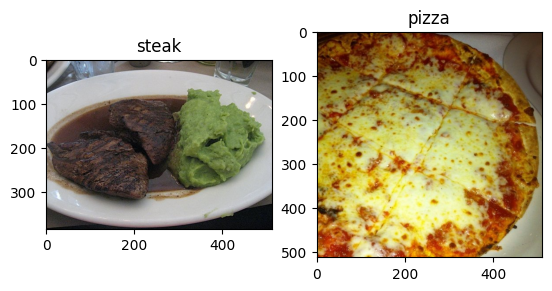

In [21]:
# Visualizing the Data:

plt.subplot(1,2,1)
steak_image = view_random_image(target_dir= 'pizza_steak/train/',
                               target_class= 'steak')

plt.subplot(1,2,2)
pizza_image = view_random_image(target_dir= 'pizza_steak/train/',
                               target_class= 'pizza')

plt.show()

### 2. Preprocess the data (prepare it for a model)

One of the most important steps for a machine learning project is creating a training and test set.

In our case, our data is already split into training and test sets. Another option here might be to create a validation set as well, but we'll leave that for now.

For an image classification project, it's standard to have your data seperated into `train` and `test` directories with subfolders in each for each class.

To start we define the training and test directory paths.

In [22]:
# Defining Training and Test Directory Path:

train_dir = 'pizza_steak/train/'
test_dir = 'pizza_steak/test/'

Our next step is to turn our data into **batches**.

A **batch** is a small subset of the dataset a model looks at during training. For example, rather than looking at 10,000 images at one time and trying to figure out the patterns, a model might only look at 32 images at a time.

It does this for a couple of reasons:
* 10,000 images (or more) might not fit into the memory of your processor (CPU or GPU).
* Trying to learn the patterns in 10,000 images in one hit could result in the model not being able to learn very well.

Why 32?

A [batch size of 32 is good for your health](https://twitter.com/ylecun/status/989610208497360896?s=20). 

32 has proven to be very effective in many different use cases and is often the default for many data preprocessing functions.

To turn our data into batches, we'll first create an instance of [`ImageDataGenerator`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator) for each of our datasets.

In [23]:
# Creating Training and Test Data Generator and Rescalling The Data:

train_datagen = ImageDataGenerator(rescale= 1/255)
test_datagen = ImageDataGenerator(rescale= 1/255)

The `ImageDataGenerator` class helps us prepare our images into batches as well as perform transformations on them as they get loaded into the model.

You might've noticed the `rescale` parameter. This is one example of the transformations we're doing.

Remember from before how we imported an image and it's pixel values were between 0 and 255?

The `rescale` parameter, along with `1/255.` is like saying "divide all of the pixel values by 255". This results in all of the image being imported and their pixel values being normalized (converted to be between 0 and 1).

For more transformation options such as data augmentation, refer to the [`ImageDataGenerator` documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator).

Now we've got a couple of ImageDataGenerator instances, we can load our images from their respective directories using the [`flow_from_directory`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator#flow_from_directory) method.

In [24]:
# Loading in Our Image Data from Directories and Turn them into Batches:

train_data = train_datagen.flow_from_directory(directory= train_dir,
                                              target_size= (224,224),
                                              class_mode= 'binary',
                                              batch_size= 32)

test_data = test_datagen.flow_from_directory(directory= test_dir,
                                            target_size= (224,224),
                                            class_mode= 'binary',
                                            batch_size= 32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


Looks like our training dataset has 1500 images belonging to 2 classes (pizza and steak) and our test dataset has 500 images also belonging to 2 classes.

Some things to here:
* Due to how our directories are structured, the classes get inferred by the subdirectory names in `train_dir` and `test_dir`.
* The `target_size` parameter defines the input size of our images in `(height, width)` format.
* The `class_mode` value of `'binary'` defines our classification problem type. If we had more than two classes, we would use `'categorical'`.
* The `batch_size` defines how many images will be in each batch, we've used 32 which is the same as the default.

We can take a look at our batched images and labels by inspecting the `train_data` object.

In [25]:
images, label = next(train_data)

In [26]:
images.shape, label.shape

((32, 224, 224, 3), (32,))

In [27]:
images[0]

array([[[0.56078434, 0.63529414, 0.79215693],
        [0.5647059 , 0.6392157 , 0.7960785 ],
        [0.5647059 , 0.6392157 , 0.80392164],
        ...,
        [0.07843138, 0.08235294, 0.05882353],
        [0.08235294, 0.08235294, 0.07450981],
        [0.09803922, 0.09803922, 0.09803922]],

       [[0.5647059 , 0.6392157 , 0.7960785 ],
        [0.5568628 , 0.6313726 , 0.7960785 ],
        [0.5568628 , 0.6313726 , 0.7960785 ],
        ...,
        [0.09803922, 0.10196079, 0.07058824],
        [0.0627451 , 0.06666667, 0.04705883],
        [0.04313726, 0.04313726, 0.03529412]],

       [[0.5686275 , 0.6431373 , 0.8078432 ],
        [0.5647059 , 0.6392157 , 0.80392164],
        [0.5647059 , 0.6392157 , 0.8078432 ],
        ...,
        [0.07450981, 0.07843138, 0.04705883],
        [0.15686275, 0.16078432, 0.13725491],
        [0.21568629, 0.21960786, 0.20000002]],

       ...,

       [[0.3921569 , 0.34901962, 0.22352943],
        [0.39607847, 0.3529412 , 0.23529413],
        [0.3372549 , 0

In [28]:
label[0]

0.0

In [30]:
# Total Number of Batches:

len(train_data)

47

### 3. Create a model (start with a baseline)

A simple heuristic for computer vision models is to use the model architecture which is performing best on [ImageNet](https://www.image-net.org/) (a large collection of diverse images to benchmark different computer vision models).

However, to begin with, it's good to build a smaller model to acquire a baseline result which you try to improve upon.

In deep learning a smaller model often refers to a model with less layers than the state of the art (SOTA). For example, a smaller model might have 3-4 layers where as a state of the art model, such as, ResNet50 might have 50+ layers.

In our case, let's take a smaller version of the model that can be found on the [CNN explainer website](https://poloclub.github.io/cnn-explainer/) (`model_1` from above) and build a 3 layer convolutional neural network.

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Flatten, MaxPool2D, Activation

In [41]:
# Building a Basic CNN:

tf.random.set_seed(42)

model_4 = Sequential()

model_4.add(InputLayer(shape= (224,224,3)))

model_4.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  strides= 1,
                  padding= 'valid',
                  activation= 'relu'))

model_4.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  strides= 1,
                  padding= 'valid',
                  activation= 'relu'))

model_4.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  strides= 1,
                  padding= 'valid',
                  activation= 'relu'))

model_4.add(Flatten())

model_4.add(Dense(units= 1, activation= 'sigmoid'))

We've got a simple convolutional neural network architecture ready to go.

And it follows the typical CNN structure of:

```
Input -> Conv + ReLU layers (non-linearities) -> Pooling layer -> Fully connected (dense layer) as Output
```

Let's discuss some of the components of the `Conv2D` layer:

* The "`2D`" means our inputs are two dimensional (height and width), even though they have 3 colour channels, the convolutions are run on each channel invididually.
* `filters` - these are the number of "feature extractors" that will be moving over our images.
* `kernel_size` - the size of our filters, for example, a `kernel_size` of `(3, 3)` (or just 3) will mean each filter will have the size 3x3, meaning it will look at a space of 3x3 pixels each time. The smaller the kernel, the more fine-grained features it will extract.
* `stride` - the number of pixels a `filter` will move across as it covers the image. A `stride` of 1 means the filter moves across each pixel 1 by 1. A `stride` of 2 means it moves 2 pixels at a time.
* `padding` - this can be either `'same'` or `'valid'`, `'same'` adds zeros the to outside of the image so the resulting output of the convolutional layer is the same as the input, where as `'valid'` (default) cuts off excess pixels where the `filter` doesn't fit (e.g. 224 pixels wide divided by a kernel size of 3 (224/3 = 74.6) means a single pixel will get cut off the end.

What's a "feature"?

A **feature** can be considered any significant part of an image. For example, in our case, a feature might be the circular shape of pizza. Or the rough edges on the outside of a steak.

It's important to note that these **features** are not defined by us, instead, the model learns them as it applies different filters across the image.

For a great demonstration of these in action, be sure to spend some time going through the following:
  * [CNN Explainer Webpage](https://poloclub.github.io/cnn-explainer/) - a great visual overview of many of the concepts we're replicating here with code.
  * [A guide to convolutional arithmetic for deep learning](https://arxiv.org/pdf/1603.07285.pdf) - a phenomenal introduction to the math going on behind the scenes of a convolutional neural network.
  * For a great explanation of padding, see this [Stack Overflow answer](https://stackoverflow.com/a/39371113/7900723).


In [42]:
# Compiling The Model:

model_4.compile(optimizer= Adam(),
               loss= tf.keras.losses.BinaryCrossentropy(),
               metrics= ['accuracy'])

In [43]:
model_4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,341 (1.82 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Fit the Model

In [44]:
history_4 = model_4.fit(train_data,
                       validation_data= test_data,
                       epochs= 5)

Epoch 1/5


2026-01-09 13:13:25.539076: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 4 bytes spill stores, 4 bytes spill loads

2026-01-09 13:13:25.547435: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 4 bytes spill stores, 4 bytes spill loads



41/47 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5607 - loss: 1.9737

2026-01-09 13:13:29.925980: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 4 bytes spill stores, 4 bytes spill loads

2026-01-09 13:13:30.007523: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 4 bytes spill stores, 4 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.6200 - loss: 1.1111 - val_accuracy: 0.7640 - val_loss: 0.5095
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7853 - loss: 0.4573 - val_accuracy: 0.8140 - val_loss: 0.4290
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8527 - loss: 0.3574 - val_accuracy: 0.8360 - val_loss: 0.3732
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9333 - loss: 0.2059 - val_accuracy: 0.8600 - val_loss: 0.3641
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9833 - loss: 0.0773 - val_accuracy: 0.8060 - val_loss: 0.4517


### 5. Evaluate the Model

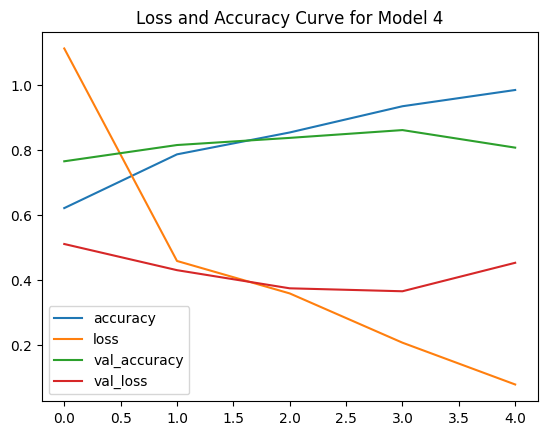

In [45]:
# Plotting The Loss and Accuracy Curve of Model:

pd.DataFrame(history_4.history).plot(title= 'Loss and Accuracy Curve for Model 4')
plt.show()

Judging by our loss curves, it looks like our model is **overfitting** the training dataset.

When a model's **validation loss starts to increase**, it's likely that it's overfitting the training dataset. This means, it's learning the patterns in the training dataset *too well* and thus its ability to generalize to unseen data will be diminished.

To further inspect our model's training performance, let's separate the accuracy and loss curves.

In [46]:
# Creating a Function to plot Training and Validtion Loss and Accuracy Curves Seperately:

def plot_loss_curves(history):
    """
    Returns Seperate Loss Curves for Training and Validation Metrics. 
    """

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(history.history['loss']))

    # Plotting Loss Curves:
    plt.plot(epochs, loss, label= 'Training Loss')
    plt.plot(epochs, val_loss, label= 'Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Plotting Accuracy Curves:
    plt.plot(epochs, accuracy, label= 'Training Accuracy')
    plt.plot(epochs, val_accuracy, label= 'Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

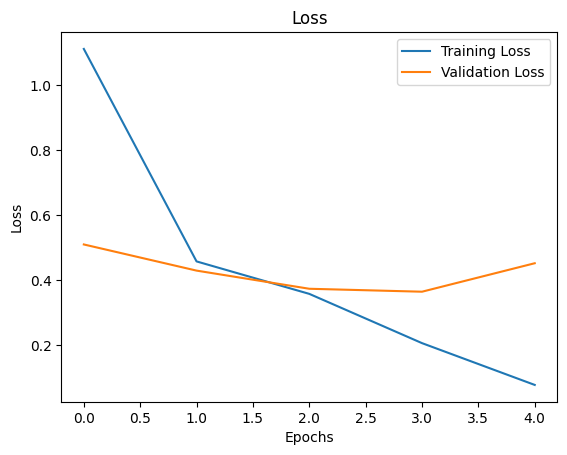

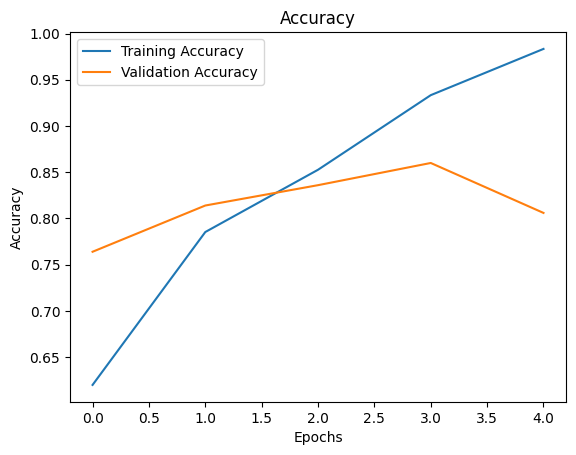

In [47]:
# Loss Curves for Model 4:
plot_loss_curves(history_4)

The ideal position for these two curves is to follow each other. If anything, the validation curve should be slightly under the training curve. If there's a large gap between the training curve and validation curve, it means your model is probably overfitting.

In [48]:
model_4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,432,025 (5.46 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 954,684 (3.64 MB)

### 6. Adjust the model parameters

Fitting a machine learning model  comes in 3 steps:
0. Create a basline.
1. Beat the baseline by overfitting a larger model.
2. Reduce overfitting.

So far we've gone through steps 0 and 1.

And there are even a few more things we could try to further overfit our model:
* Increase the number of convolutional layers.
* Increase the number of convolutional filters.
* Add another dense layer to the output of our flattened layer.

But what we'll do instead is focus on getting our model's training curves to better align with eachother, in other words, we'll take on step 2.

Why is reducing overfitting important?

When a model performs too well on training data and poorly on unseen data, it's not much use to us if we wanted to use it in the real world.

Say we were building a pizza vs. steak food classifier app, and our model performs very well on our training data but when users tried it out, they didn't get very good results on their own food images, is that a good experience?

So for the next few models we build, we're going to adjust a number of parameters and inspect the training curves along the way.

Namely, we'll build 2 more models:
* A ConvNet with [max pooling](https://deeplizard.com/learn/video/ZjM_XQa5s6s)
* A ConvNet with max pooling and data augmentation

For the first model, we'll follow the modified basic CNN structure:

```
Input -> Conv layers + ReLU layers (non-linearities) + Max Pooling layers -> Fully connected (dense layer) as Output
```

Let's built it. It'll have the same structure as `model_4` but with a [`MaxPool2D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D) layer after each convolutional layer.

In [49]:
# Creating a CNN with Maxpool2D Layers:

tf.random.set_seed(42)

model_5 = Sequential()

model_5.add(InputLayer(shape= (224,224,3)))

model_5.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))
model_5.add(MaxPool2D(pool_size= 2))

model_5.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))
model_5.add(MaxPool2D(pool_size= 2))

model_5.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))
model_5.add(MaxPool2D(pool_size= 2))

model_5.add(Flatten())

model_5.add(Dense(units= 1, activation= 'sigmoid'))

If convolutional layers learn the features of an image you can think of a Max Pooling layer as figuring out the *most important* of those features.

In [50]:
# Compiling The Model:

model_5.compile(optimizer= Adam(),
               loss= tf.keras.losses.BinaryCrossentropy(),
               metrics= ['accuracy'])

In [51]:
# Fitting The Model:

history_5 = model_5.fit(train_data,
                       validation_data= test_data,
                       epochs= 5)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.6847 - loss: 0.5919 - val_accuracy: 0.8060 - val_loss: 0.4817
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8013 - loss: 0.4540 - val_accuracy: 0.8520 - val_loss: 0.3549
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8207 - loss: 0.4006 - val_accuracy: 0.8340 - val_loss: 0.3657
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8440 - loss: 0.3829 - val_accuracy: 0.8600 - val_loss: 0.3331
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8400 - loss: 0.3586 - val_accuracy: 0.8620 - val_loss: 0.3099


It looks like our model with max pooling (`model_5`) is performing worse on the training set but better on the validation set.

In [52]:
model_5.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

Do you notice what's going on here with the output shape in each `MaxPooling2D` layer?

It gets halved each time. This is effectively the `MaxPooling2D` layer taking the outputs of each Conv2D layer and saying "I only want the most important features, get rid of the rest".

The bigger the `pool_size` parameter, the more the max pooling layer will squeeze the features out of the image. However, too big and the model might not be able to learn anything.

The results of this pooling are seen in a major reduction of total trainable parameters (8,861 in `model_5` and 477,431 in `model_4`).

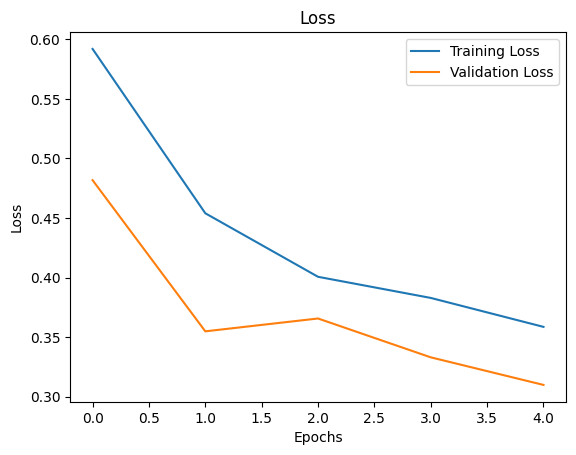

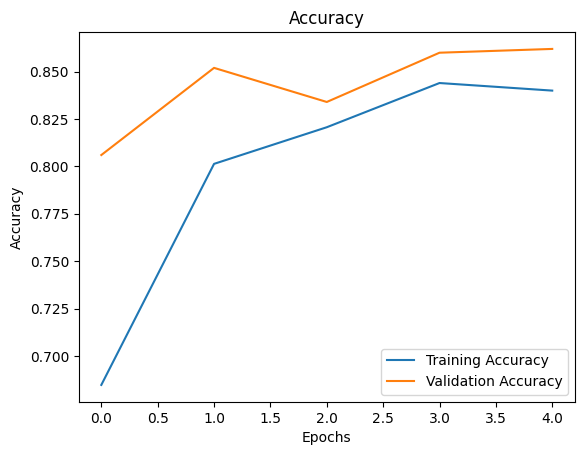

In [53]:
# Plotting Loss and Accuracy Curves:
plot_loss_curves(history_5)

Time to try another method of overfitting prevention, data augmentation.

To implement data augmentation, we'll have to reinstantiate our [`ImageDataGenerator`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator) instances.

In [54]:
# Creating ImageDataGenerator training instance with Data Augmentation:

train_datagen_augmented = ImageDataGenerator(rescale= 1/255,
                                            rotation_range= 20, # rotate the image slightly between 0 and 20 degrees
                                            shear_range= 0.2, # shear the image
                                            zoom_range= 0.2, # zoom into the image
                                            width_shift_range= 0.2, # shift the image width ways
                                            height_shift_range= 0.2, # shift the image height ways
                                            horizontal_flip= True) # flip the image on the horizontal axis

# Create Image Data Generator Without Data Augmentation:
train_datagen = ImageDataGenerator(rescale= 1/255)

# Create Image Data Generator for Test Data Without Data Augmentation:
test_datagen = ImageDataGenerator(rescale= 1/255)

What's data augmentation?

**Data augmentation** is the process of altering our training data, leading to it having more diversity and in turn allowing our models to learn more generalizable patterns. Altering might mean adjusting the rotation of an image, flipping it, cropping it or something similar.

Doing this simulates the kind of data a model might be used on in the real world.

If we're building a pizza vs. steak application, not all of the images our users take might be in similar setups to our training data. Using data augmentation gives us another way to prevent overfitting and in turn make our model more generalizable.

Data augmentation is usally only performed on the training data. Using the `ImageDataGenerator` built-in data augmentation parameters our images are left as they are in the directories but are randomly manipulated when loaded into the model.

In [62]:
# Importing Data from Trainig Directory and Augment it:
train_data_augmented = train_datagen_augmented.flow_from_directory(directory= train_dir,
                                                                  target_size= (224,224),
                                                                  batch_size= 32,
                                                                  class_mode= 'binary',
                                                                  shuffle= False)

# Creating Non-Augmented Data Batches from Trainig Directory:
train_data = train_datagen.flow_from_directory(directory= train_dir,
                                              target_size= (224,224),
                                              batch_size= 32,
                                              class_mode= 'binary',
                                              shuffle= False)

# Create Non-Augmented Data Batches from Testing Directory:
test_data = test_datagen.flow_from_directory(directory= test_dir,
                                            target_size= (224,224),
                                            batch_size= 32,
                                            class_mode= 'binary')

Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [63]:
# Getting a Sample Batches from Augmented and Non-Augmented Training Data:

images, labels = next(train_data)
images_aug, labels_aug = next(train_data_augmented)

In [64]:
print(images.shape, labels.shape)
print(images_aug.shape, labels_aug.shape)

(32, 224, 224, 3) (32,)
(32, 224, 224, 3) (32,)


In [65]:
print(len(images), len(images_aug))

32 32


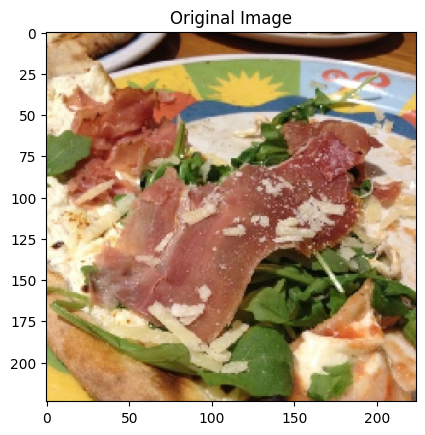

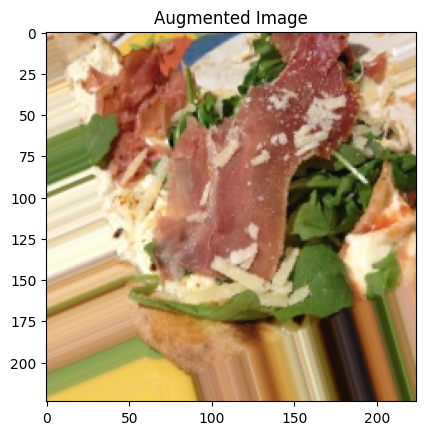

In [69]:
# Visualizing Random Image and It's Augmented Version:

random_number = random.randint(0, 31)

plt.imshow(images[random_number])
plt.title('Original Image')
plt.show()

plt.imshow(images_aug[random_number])
plt.title('Augmented Image')
plt.show()

After going through a sample of original and augmented images, we can start to see some of the example transformations on the training images.

Notice how some of the augmented images look like slightly warped versions of the original image. This means our model will be forced to try and learn patterns in less-than-perfect images, which is often the case when using real-world images.

Should we use data augmentation? And how much should we augment?

Data augmentation is a way to try and prevent a model overfitting. If your model is overfiting (e.g. the validation loss keeps increasing), you may want to try using data augmentation.

As for how much to data augment, there's no set practice for this. Best to check out the options in the `ImageDataGenerator` class and think about how a model in your use case might benefit from some data augmentation.